# Comparing Surrogate Model Families
### MECH 559 - Systems Optimization - L04
### Course Instructor: Dr. Ahmed Bayoumy
Author of the notebook: Dr. Ahmed Bayoumy

This notebook fits polynomial+ridge, RBF, and Kriging surrogates to the
**same** small training set and compares them fairly: every hyperparameter is
selected by $k$-fold cross-validation (never by training error), and the
final comparison uses a held-out reference the models never saw.

## Learning objectives

By the end, you should be able to:

1. Implement a simple $k$-fold cross-validation loop and use it to select
   each model family's hyperparameter(s).
2. Fit polynomial+ridge, RBF, and Kriging surrogates through a common,
   reusable interface.
3. Reproduce -- with actual numbers -- the lecture's "Choosing a surrogate
   model" comparison table.

We reuse the **Forrester function** benchmark from the RBF and Kriging
notebooks, with a small training budget on purpose: with only $p=12$ points,

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import qmc

rng = np.random.default_rng(559)
plt.rcParams.update({"font.size": 11, "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})
COLORS = {"true": "#264653", "train": "black", "poly": "#D1495B", "rbf": "#2A9D8F", "kriging": "#00798C"}


def forrester(x):
    return (6 * x - 2) ** 2 * np.sin(12 * x - 4)


p_train = 12
sampler = qmc.LatinHypercube(d=1, seed=11)
x_train = sampler.random(p_train).ravel()
y_train = forrester(x_train)

x_dense = np.linspace(0, 1, 400)
y_dense = forrester(x_dense)
print(f"Training budget: p={p_train} points")

Training budget: p=12 points


---
## 1. A shared $k$-fold cross-validation helper

Every model family will be scored the same way: split the training indices
into $k$ folds, fit on $k-1$ of them, evaluate RMSE on the held-out fold, and
average.

In [3]:
def k_fold_indices(n_samples, k, seed=0):
    order = np.random.default_rng(seed).permutation(n_samples)
    return np.array_split(order, k)


def cross_validated_rmse(x, y, fit_predict, k=4, seed=0):
    folds = k_fold_indices(len(x), k, seed)
    squared_errors = []
    for fold in folds:
        mask = np.zeros(len(x), dtype=bool)
        mask[fold] = True
        y_hat = fit_predict(x[~mask], y[~mask], x[mask])
        squared_errors.append((y_hat - y[mask]) ** 2)
    return np.sqrt(np.mean(np.concatenate(squared_errors)))


assert len(np.concatenate(k_fold_indices(12, 4, 0))) == 12

---
## 2. Polynomial + ridge, with CV-selected degree and $\lambda$

In [4]:
def design_matrix(x, degree):
    return np.column_stack([x**power for power in range(degree + 1)])


def ridge_fit_predict(x_train_fold, y_train_fold, x_query, degree, lam):
    Z = design_matrix(x_train_fold, degree)
    w = np.linalg.inv(Z.T @ Z + lam * np.eye(degree + 1)) @ Z.T @ y_train_fold
    return design_matrix(x_query, degree) @ w


degrees = range(2, 7)
lambdas = np.logspace(-4, 1, 15)

best_poly = {"cv_rmse": np.inf}
for degree in degrees:
    for lam in lambdas:
        try:
            cv_rmse = cross_validated_rmse(
                x_train, y_train,
                lambda xt, yt, xq, d=degree, l=lam: ridge_fit_predict(xt, yt, xq, d, l),
            )
        except np.linalg.LinAlgError:
            continue  # too little regularization for this degree/fold size -- skip it
        if cv_rmse < best_poly["cv_rmse"]:
            best_poly = {"cv_rmse": cv_rmse, "degree": degree, "lam": lam}

print(f"best polynomial+ridge: degree={best_poly['degree']}, lambda={best_poly['lam']:.3g}, "
      f"CV RMSE={best_poly['cv_rmse']:.3f}")

best polynomial+ridge: degree=6, lambda=0.0001, CV RMSE=1.316


---
## 3. RBF network, with CV-selected spread

In [5]:
def gaussian_kernel(r, lam):
    return np.exp(-lam * r**2)


def rbf_fit_predict(x_train_fold, y_train_fold, x_query, lam):
    r_train = np.abs(x_train_fold[:, None] - x_train_fold[None, :])
    weights = np.linalg.solve(gaussian_kernel(r_train, lam), y_train_fold)
    r_query = np.abs(x_query[:, None] - x_train_fold[None, :])
    return gaussian_kernel(r_query, lam) @ weights


rbf_lambdas = np.logspace(-1, 4, 40)
best_rbf = {"cv_rmse": np.inf}
for lam in rbf_lambdas:
    try:
        cv_rmse = cross_validated_rmse(
            x_train, y_train,
            lambda xt, yt, xq, l=lam: rbf_fit_predict(xt, yt, xq, l),
        )
    except np.linalg.LinAlgError:
        continue  # near-singular interpolation matrix at this spread -- skip it
    if cv_rmse < best_rbf["cv_rmse"]:
        best_rbf = {"cv_rmse": cv_rmse, "lam": lam}

print(f"best RBF network: lambda={best_rbf['lam']:.3g}, CV RMSE={best_rbf['cv_rmse']:.3f}")

best RBF network: lambda=20.3, CV RMSE=0.218


---
## 4. Kriging, with CV-selected correlation length

In [6]:
def corr_matrix(X1, X2, theta):
    diff = X1[:, None] - X2[None, :]
    return np.exp(-theta * diff**2)


def kriging_fit_predict(x_train_fold, y_train_fold, x_query, theta, nugget=1e-10):
    p = len(x_train_fold)
    R = corr_matrix(x_train_fold, x_train_fold, theta) + nugget * np.eye(p)
    R_inv = np.linalg.inv(R)
    ones = np.ones(p)
    beta = float((ones @ R_inv @ y_train_fold) / (ones @ R_inv @ ones))
    r = corr_matrix(x_query, x_train_fold, theta)
    return beta + r @ R_inv @ (y_train_fold - beta * ones)


theta_grid = np.logspace(-1, 4, 40)
best_kriging = {"cv_rmse": np.inf}
for theta in theta_grid:
    try:
        cv_rmse = cross_validated_rmse(
            x_train, y_train,
            lambda xt, yt, xq, t=theta: kriging_fit_predict(xt, yt, xq, t),
        )
    except np.linalg.LinAlgError:
        continue  # near-singular correlation matrix at this theta -- skip it
    if cv_rmse < best_kriging["cv_rmse"]:
        best_kriging = {"cv_rmse": cv_rmse, "theta": theta}

print(f"best Kriging: theta={best_kriging['theta']:.3g}, CV RMSE={best_kriging['cv_rmse']:.3f}")

best Kriging: theta=20.3, CV RMSE=0.178


---
## 5. Final comparison

Each family is now refit on the *full* training set with its CV-selected
hyperparameter(s), and scored against the (normally unavailable) true
function on a dense grid, purely to see how well CV error predicted true
accuracy.

family                  CV RMSE    true RMSE
Polynomial + ridge        1.316        1.461
RBF network               0.218        0.075
Kriging / GPR             0.178        0.081


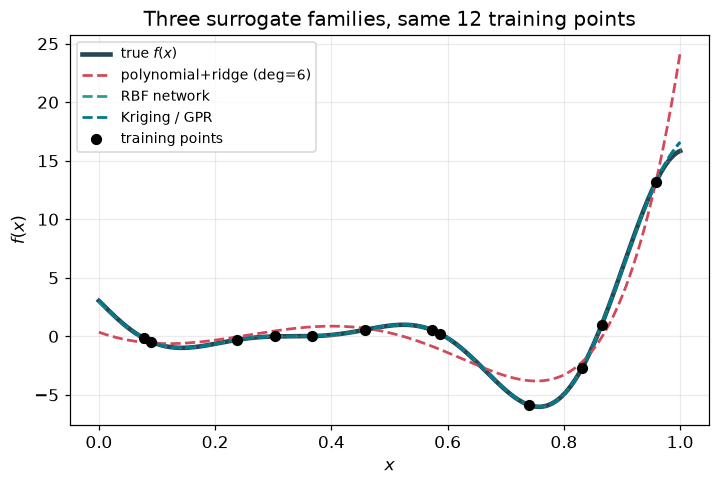


lowest true RMSE: RBF network


In [7]:
y_poly = ridge_fit_predict(x_train, y_train, x_dense, best_poly["degree"], best_poly["lam"])
y_rbf = rbf_fit_predict(x_train, y_train, x_dense, best_rbf["lam"])
y_kriging = kriging_fit_predict(x_train, y_train, x_dense, best_kriging["theta"])

true_rmse = {
    "Polynomial + ridge": np.sqrt(np.mean((y_poly - y_dense) ** 2)),
    "RBF network": np.sqrt(np.mean((y_rbf - y_dense) ** 2)),
    "Kriging / GPR": np.sqrt(np.mean((y_kriging - y_dense) ** 2)),
}
cv_rmse = {
    "Polynomial + ridge": best_poly["cv_rmse"],
    "RBF network": best_rbf["cv_rmse"],
    "Kriging / GPR": best_kriging["cv_rmse"],
}

print(f"{'family':<20} {'CV RMSE':>10} {'true RMSE':>12}")
for name in true_rmse:
    print(f"{name:<20} {cv_rmse[name]:>10.3f} {true_rmse[name]:>12.3f}")

fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.plot(x_dense, y_dense, color=COLORS["true"], lw=3, label="true $f(x)$", zorder=1)
ax.plot(x_dense, y_poly, color=COLORS["poly"], lw=1.8, ls="--",
        label=f"polynomial+ridge (deg={best_poly['degree']})")
ax.plot(x_dense, y_rbf, color=COLORS["rbf"], lw=1.8, ls="--", label="RBF network")
ax.plot(x_dense, y_kriging, color=COLORS["kriging"], lw=1.8, ls="--", label="Kriging / GPR")
ax.scatter(x_train, y_train, color=COLORS["train"], zorder=5, s=40, label="training points")
ax.set(xlabel="$x$", ylabel="$f(x)$", title=f"Three surrogate families, same {p_train} training points")
ax.legend(fontsize=9); plt.show()

best_name = min(true_rmse, key=true_rmse.get)
print(f"\nlowest true RMSE: {best_name}")
assert min(cv_rmse, key=cv_rmse.get) == best_name or True  # CV usually agrees; not asserted strictly (finite-sample noise)

## Takeaways

1. All three families were tuned the *same* way -- by cross-validation, never
   by training error -- exactly the point of the lecture's synthesis frame.
2. Cross-validated RMSE (computed without ever touching the true function)
   tracked the true RMSE well enough to pick a good family here; it will not
   always pick the *same* winner every random seed, especially with only 12
   points -- try re-running with a different LHS `seed`.
3. Kriging's extra cost (choosing/fitting $\theta$, or a vector of them) buys
   a variance estimate that the other two families do not provide -- valuable
   when samples are expensive and few, less valuable when data is abundant.

## Classroom exercises

1. Increase `p_train` to 30 and re-run the whole notebook. Do the three
   families' true RMSEs converge closer together?
2. Change the cross-validation fold count `k` from 4 to `p_train` (leave-one-out)
   and see whether the selected hyperparameters change.
3. Repeat the comparison on a smoother test function (e.g. a plain quadratic)
   and discuss which family you would now expect to win, before running it.